In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
dataset=pd.read_csv(r'NEPSE_2020_to_2025_.csv')

In [3]:
dataset

,Unnamed: 0,Date,Index Value
0,0,01-01-2020,1169.50
1,1,02-01-2020,1166.21
2,2,05-01-2020,1182.31
3,3,06-01-2020,1200.69
4,4,07-01-2020,1216.92
...,...,...,...
1344,1344,23-12-2025,2584.49
1345,1345,24-12-2025,2585.87
1346,1346,28-12-2025,2633.42
1347,1347,29-12-2025,2622.88


In [4]:
dataset.drop(['Unnamed: 0'],axis=1,inplace=True)

In [5]:
dataset

,Date,Index Value
0,01-01-2020,1169.50
1,02-01-2020,1166.21
2,05-01-2020,1182.31
3,06-01-2020,1200.69
4,07-01-2020,1216.92
...,...,...
1344,23-12-2025,2584.49
1345,24-12-2025,2585.87
1346,28-12-2025,2633.42
1347,29-12-2025,2622.88


In [6]:
latex_code = dataset.to_latex(index=False)  # index=False removes the row numbers
print(latex_code)

\begin{tabular}{lr}
\toprule
Date & Index Value \\
\midrule
01-01-2020 & 1169.500000 \\
02-01-2020 & 1166.210000 \\
05-01-2020 & 1182.310000 \\
06-01-2020 & 1200.690000 \\
07-01-2020 & 1216.920000 \\
08-01-2020 & 1209.600000 \\
09-01-2020 & 1213.110000 \\
12-01-2020 & 1255.720000 \\
13-01-2020 & 1270.860000 \\
14-01-2020 & 1263.380000 \\
15-01-2020 & 1284.230000 \\
16-01-2020 & 1310.230000 \\
19-01-2020 & 1343.650000 \\
20-01-2020 & 1317.110000 \\
21-01-2020 & 1320.470000 \\
22-01-2020 & 1313.420000 \\
23-01-2020 & 1297.470000 \\
26-01-2020 & 1276.680000 \\
27-01-2020 & 1300.620000 \\
28-01-2020 & 1306.150000 \\
29-01-2020 & 1305.880000 \\
30-01-2020 & 1325.380000 \\
02-02-2020 & 1346.640000 \\
03-02-2020 & 1349.130000 \\
04-02-2020 & 1337.040000 \\
05-02-2020 & 1342.360000 \\
06-02-2020 & 1333.690000 \\
09-02-2020 & 1319.990000 \\
10-02-2020 & 1324.260000 \\
11-02-2020 & 1341.380000 \\
12-02-2020 & 1345.970000 \\
13-02-2020 & 1344.590000 \\
16-02-2020 & 1363.970000 \\
17-02-2020 & 139

In [7]:
dataset.tail(10)

,Date,Index Value
1339,16-12-2025,2619.99
1340,17-12-2025,2625.69
1341,18-12-2025,2615.03
1342,21-12-2025,2595.10
1343,22-12-2025,2581.21
1344,23-12-2025,2584.49
1345,24-12-2025,2585.87
1346,28-12-2025,2633.42
1347,29-12-2025,2622.88
1348,31-12-2025,2633.76


In [8]:

dataset['log_return'] = np.log(dataset['Index Value'] / dataset['Index Value'].shift(1))
dataset = dataset.dropna()

In [9]:
dataset

,Date,Index Value,log_return
1,02-01-2020,1166.21,-0.002817
2,05-01-2020,1182.31,0.013711
3,06-01-2020,1200.69,0.015426
4,07-01-2020,1216.92,0.013427
5,08-01-2020,1209.60,-0.006033
...,...,...,...
1344,23-12-2025,2584.49,0.001270
1345,24-12-2025,2585.87,0.000534
1346,28-12-2025,2633.42,0.018221
1347,29-12-2025,2622.88,-0.004010


In [10]:
sigma = dataset['log_return'].std()

In [11]:
sigma

np.float64(0.014947753845004933)

In [12]:
dt = 1/252
mu = dataset['log_return'].mean()/dt + 0.5 * sigma**2

In [13]:
mu

np.float64(0.1518793113969448)

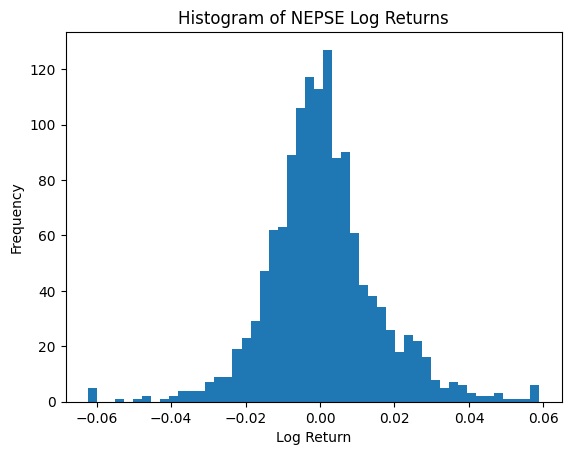

In [14]:
import scipy.stats as stats
from statsmodels.stats.stattools import jarque_bera
plt.hist(dataset['log_return'], bins=50)
plt.title("Histogram of NEPSE Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()


In [15]:
dataset.describe()

,Index Value,log_return
count,1348.000000,1348.000000
mean,2268.276543,0.000602
std,456.675132,0.014948
min,1166.210000,-0.062262
25%,1962.375000,-0.007693
50%,2180.460000,-0.000211
75%,2662.205000,0.007476
max,3198.600000,0.058847


In [16]:
print(dataset.describe().to_latex(index=True))

\begin{tabular}{lrr}
\toprule
 & Index Value & log_return \\
\midrule
count & 1348.000000 & 1348.000000 \\
mean & 2268.276543 & 0.000602 \\
std & 456.675132 & 0.014948 \\
min & 1166.210000 & -0.062262 \\
25% & 1962.375000 & -0.007693 \\
50% & 2180.460000 & -0.000211 \\
75% & 2662.205000 & 0.007476 \\
max & 3198.600000 & 0.058847 \\
\bottomrule
\end{tabular}



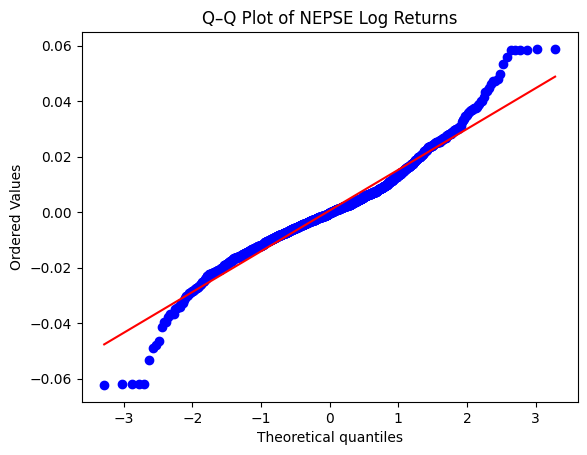

In [17]:
stats.probplot(dataset['log_return'], dist="norm", plot=plt)
plt.title("Q–Q Plot of NEPSE Log Returns")
plt.show()


In [18]:
shapiro_stat, shapiro_p = stats.shapiro(dataset['log_return'])

print("Shapiro-Wilk statistic:", shapiro_stat)
print("p-value:", shapiro_p)


Shapiro-Wilk statistic: 0.9644651832142275
p-value: 1.17556650106567e-17


In [19]:
jb_stat, jb_p, skew, kurt = jarque_bera(dataset['log_return'])

print("Jarque-Bera statistic:", jb_stat)
print("p-value:", jb_p)
print("Skewness:", skew)
print("Kurtosis:", kurt)


Jarque-Bera statistic: 325.0483492031868
p-value: 2.6100437952519587e-71
Skewness: 0.23884443558401305
Kurtosis: 5.35775832251826


In [20]:
S0 = dataset['Index Value'].iloc[-1]   # last observed value
T = 1.0                           # 1 year forecast
N = int(T / dt)                   # number of steps


In [43]:
S0

np.float64(2633.76)

In [21]:
np.random.seed(42)

Z = np.random.normal(0, 1, N)

S = np.zeros(N)
S[0] = S0

for t in range(1, N):
    S[t] = S[t-1] * np.exp(
        (mu - 0.5 * sigma**2) * dt +
        sigma * np.sqrt(dt) * Z[t]
    )


In [22]:
n_sim = 1000
S_paths = np.zeros((N, n_sim))
S_paths[0] = S0

for i in range(n_sim):
    Z = np.random.normal(0, 1, N)
    for t in range(1, N):
        S_paths[t, i] = S_paths[t-1, i] * np.exp(
            (mu - 0.5 * sigma**2) * dt +
            sigma * np.sqrt(dt) * Z[t]
        )


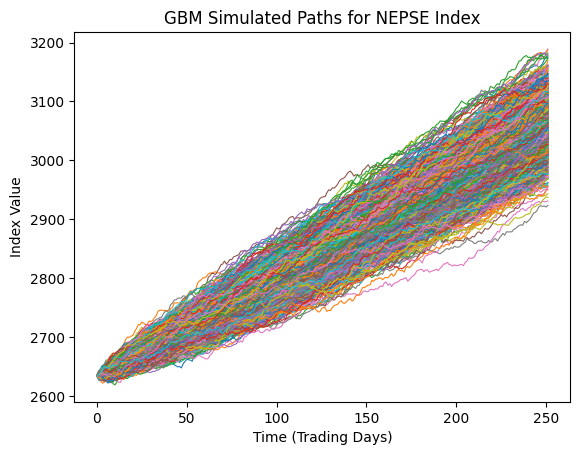

In [23]:
import matplotlib.pyplot as plt

plt.plot(S_paths, linewidth=0.8)
plt.title("GBM Simulated Paths for NEPSE Index")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Index Value")
plt.show()


In [24]:
T = 1.0  # 1 year
expected_value = S0 * np.exp(mu * T)

print("Expected index value after 1 year:", expected_value)


Expected index value after 1 year: 3065.7486410562874


In [25]:
predicted_mean = S_paths[-1].mean()

print("Mean of simulated index values after 1 year:", predicted_mean)


Mean of simulated index values after 1 year: 3063.8800819295166


In [26]:
lower = np.percentile(S_paths[-1], 5)
upper = np.percentile(S_paths[-1], 95)

print("5% percentile:", lower)
print("95% percentile:", upper)


5% percentile: 2988.753628948203
95% percentile: 3138.3928065121504


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Historical
historical_index = dataset['Index Value'].values

# Number of simulations
n_sim = 1000
N = len(historical_index)
S_paths = np.zeros((N, n_sim))
S_paths[0] = historical_index[0]

np.random.seed(42)
for i in range(n_sim):
    Z = np.random.normal(0, 1, N)
    for t in range(1, N):
        S_paths[t, i] = S_paths[t-1, i] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t]
        )

# Mean of simulated paths
sim_mean = S_paths.mean(axis=1)


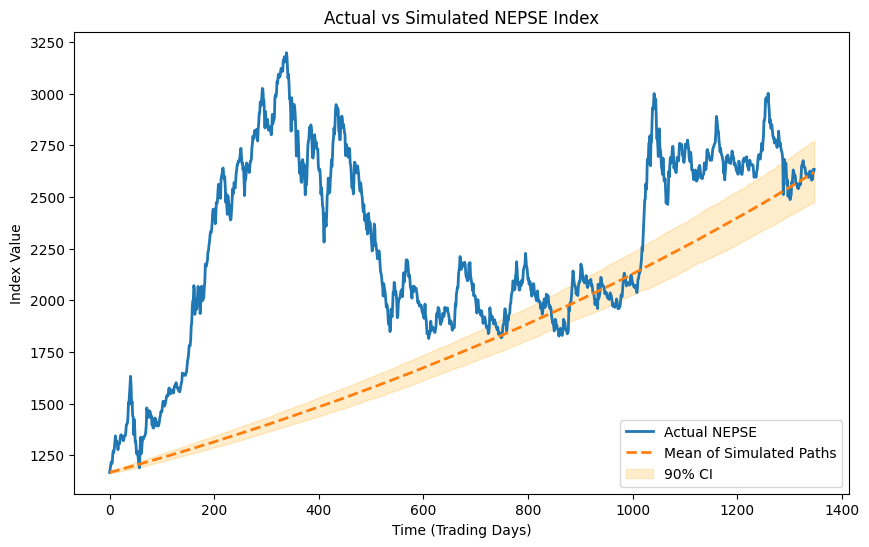

In [46]:
plt.figure(figsize=(10,6))
plt.plot(historical_index, label="Actual NEPSE", linewidth=2)
plt.plot(sim_mean, label="Mean of Simulated Paths", linewidth=2, linestyle='--')
plt.fill_between(range(N),
                 np.percentile(S_paths, 5, axis=1),
                 np.percentile(S_paths, 95, axis=1),
                 color='orange', alpha=0.2, label='90% CI')
plt.title("Actual vs Simulated NEPSE Index")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Index Value")
plt.legend()
plt.show()


In [29]:
from scipy.stats import skew, kurtosis

In [30]:
actual_returns=dataset['log_return']

In [31]:
# Time step (daily data)
dt = 1 / 252

# Number of observations (same length as actual returns)
n = len(actual_returns)

# Random normal shocks
Z = np.random.normal(0, 1, n)

# Simulated log returns (GBM)
simulated_returns = (
    (mu - 0.5 * sigma**2) * dt
    + sigma * np.sqrt(dt) * Z
)


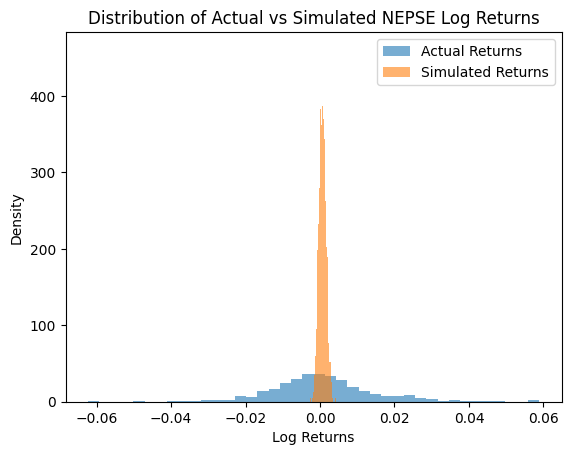

In [32]:
plt.hist(actual_returns, bins=40, density=True, alpha=0.6, label='Actual Returns')
plt.hist(simulated_returns, bins=40, density=True, alpha=0.6, label='Simulated Returns')

plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.title('Distribution of Actual vs Simulated NEPSE Log Returns')
plt.legend()
plt.show()


In [33]:
comparison = pd.DataFrame({
    'Actual Returns': [
        actual_returns.mean(),
        actual_returns.std(),
        skew(actual_returns),
        kurtosis(actual_returns)
    ],
    'Simulated Returns': [
        simulated_returns.mean(),
        simulated_returns.std(),
        skew(simulated_returns),
        kurtosis(simulated_returns)
    ]
}, index=['Mean', 'Std Dev', 'Skewness', 'Kurtosis'])

comparison


,Actual Returns,Simulated Returns
Mean,0.000602,0.000654
Std Dev,0.014948,0.000947
Skewness,0.238844,0.077803
Kurtosis,2.357758,-0.086356


In [34]:
print(comparison.to_latex(index=True))

\begin{tabular}{lrr}
\toprule
 & Actual Returns & Simulated Returns \\
\midrule
Mean & 0.000602 & 0.000654 \\
Std Dev & 0.014948 & 0.000947 \\
Skewness & 0.238844 & 0.077803 \\
Kurtosis & 2.357758 & -0.086356 \\
\bottomrule
\end{tabular}



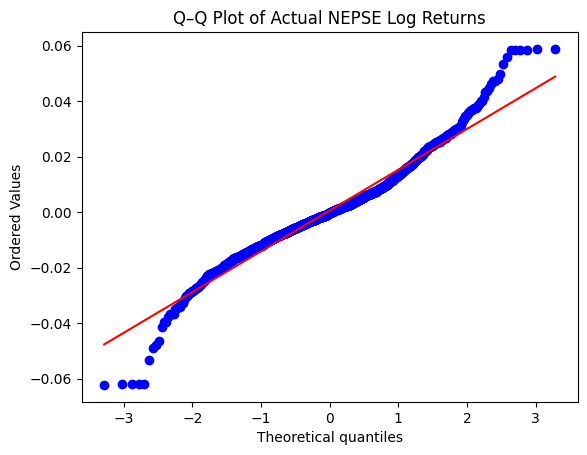

In [35]:
import scipy.stats as stats

stats.probplot(actual_returns, dist="norm", plot=plt)
plt.title("Q–Q Plot of Actual NEPSE Log Returns")
plt.show()


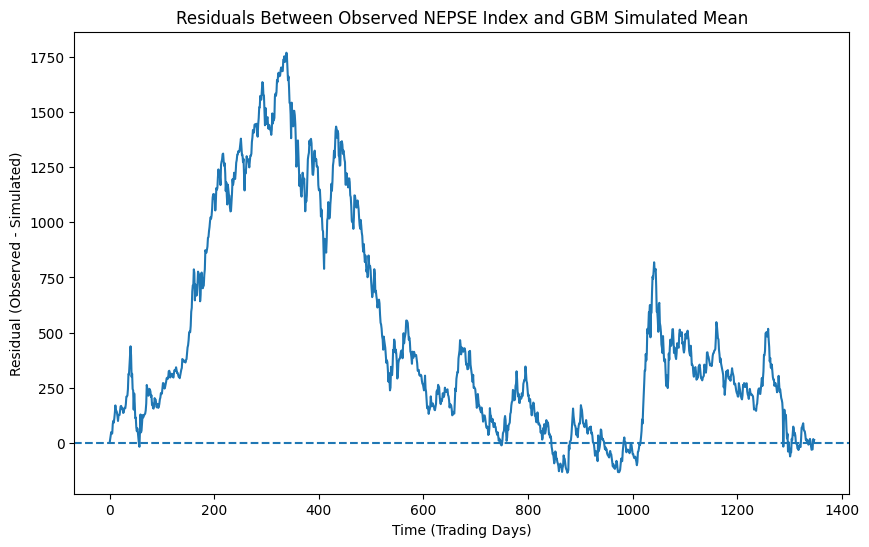

In [36]:
# -----------------------------------------------------
# Residual (Error) computation
# -----------------------------------------------------
# Mean across all simulated paths at each time t
simulated_mean = S_paths.mean(axis=1)
residuals = historical_index - simulated_mean

# -----------------------------------------------------
# Residual plot
# -----------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals Between Observed NEPSE Index and GBM Simulated Mean")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Residual (Observed - Simulated)")
plt.show()


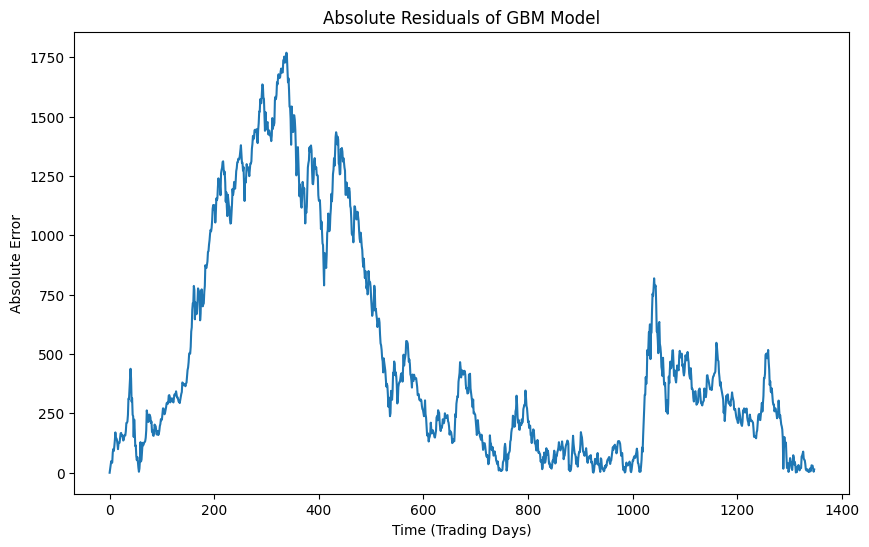

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(np.abs(residuals))
plt.title("Absolute Residuals of GBM Model")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Absolute Error")
plt.show()


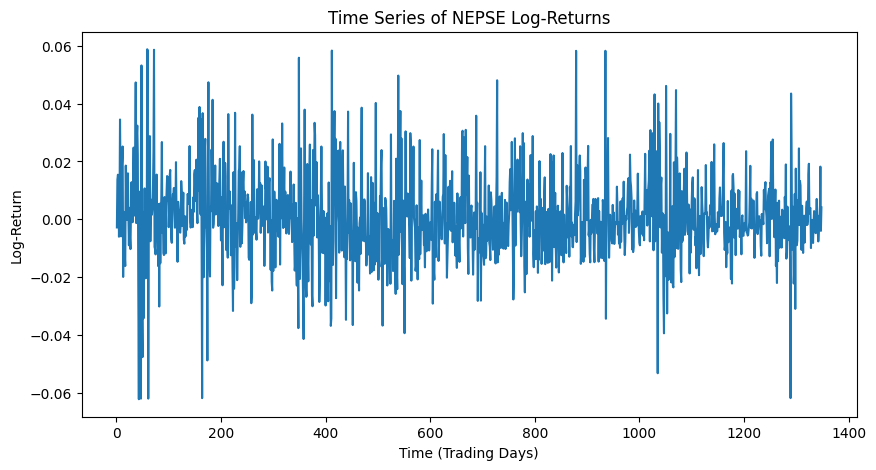

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(dataset['log_return'])
plt.title("Time Series of NEPSE Log-Returns")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Log-Return")
plt.show()


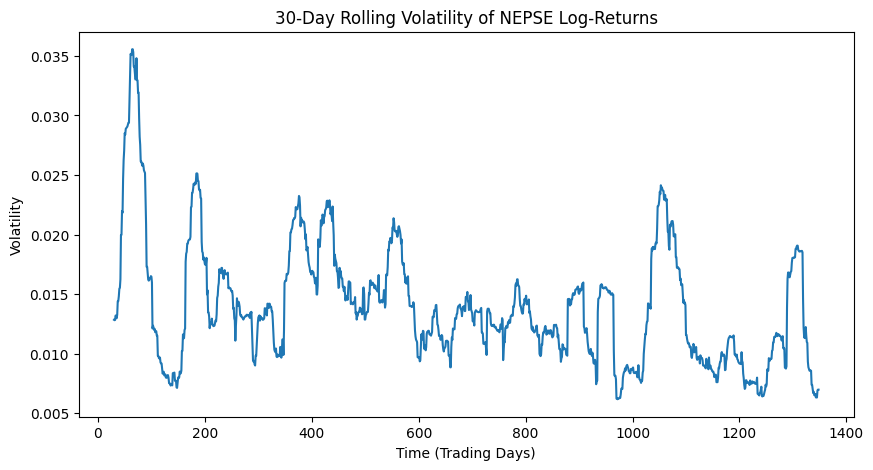

In [39]:
rolling_vol = dataset['log_return'].rolling(window=30).std()

plt.figure(figsize=(10, 5))
plt.plot(rolling_vol)
plt.title("30-Day Rolling Volatility of NEPSE Log-Returns")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Volatility")
plt.show()


In [40]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

In [41]:
mean_absolute_error(simulated_returns,actual_returns)

0.010912311271971618

In [42]:
root_mean_squared_error(simulated_returns,actual_returns)

0.01501824973357377